Group #: 6

Group Members:
* Hashim Ali Aljarrash : 2230000215
* Ahmad Muhanna : 2230006180
* Mohammed Alammari : 2230003182
* Ali Alshehri : 2230002515
* Osama Al Haddaf: 2230001201

# installing pytorch

In [4]:
# FOR AMD
#pip install --no-cache-dir https://repo.radeon.com/rocm/windows/rocm-rel-7.2.1/rocm_sdk_core-7.2.1-py3-none-win_amd64.whl https://repo.radeon.com/rocm/windows/rocm-rel-7.2.1/rocm_sdk_devel-7.2.1-py3-none-win_amd64.whl https://repo.radeon.com/rocm/windows/rocm-rel-7.2.1/rocm_sdk_libraries_custom-7.2.1-py3-none-win_amd64.whl https://repo.radeon.com/rocm/windows/rocm-rel-7.2.1/rocm-7.2.1.tar.gz
#pip install --no-cache-dir https://repo.radeon.com/rocm/windows/rocm-rel-7.2.1/torch-2.9.1%2Brocm7.2.1-cp312-cp312-win_amd64.whl https://repo.radeon.com/rocm/windows/rocm-rel-7.2.1/torchaudio-2.9.1%2Brocm7.2.1-cp312-cp312-win_amd64.whl https://repo.radeon.com/rocm/windows/rocm-rel-7.2.1/torchvision-0.24.1%2Brocm7.2.1-cp312-cp312-win_amd64.whl

In [5]:
#nvidia
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu132

# Libraries Import

In [1]:
import random
import torch
import torchvision
#-------------------------------------
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
#------------------------------------------
import matplotlib.pyplot as plt
#--------------------------------
import torch.nn as nn
import torch.nn.functional as F
#--------------------------------
import torch.optim as optim
from torch.utils.data import random_split


SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
g = torch.Generator()
g.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# The device working on CPU or GPU:

In [2]:
# working with cpu currently because of amd GPU support inconsistency
print("PyTorch version: {}".format(torch.__version__))
print("Torchvision version: {}".format(torchvision.__version__))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: {}".format(device))

PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu
Using device: cpu


# Task 2 loading the dataset

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train dataset size: {}".format(len(train_dataset)))
print("Test dataset size: {}".format(len(test_dataset)))

Train dataset size: 60000
Test dataset size: 10000


# Task 3 inspect the dataset

Images tensor shape: torch.Size([32, 1, 28, 28])
Labels tensor shape: torch.Size([32])


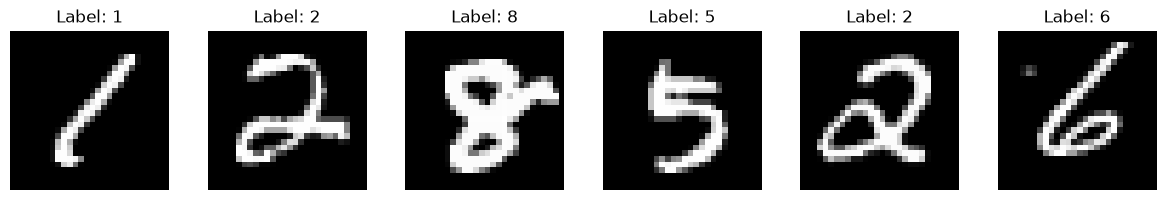

In [4]:
images, labels = next(iter(train_loader))
print("Images tensor shape: {}".format(images.shape))
print("Labels tensor shape: {}".format(labels.shape))

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(images[i][0], cmap="gray")
    axes[i].set_title("Label: {}".format(labels[i].item()))
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# Task 4 Creating the simple neural network

In [5]:
class SimpleNeuralNetwork(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super(SimpleNeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net = SimpleNeuralNetwork()
print(net)

sample, _ = next(iter(train_loader))
flattened = torch.flatten(sample, start_dim=1)
output = net(sample)
print("Input shape: {}".format(sample.shape))
print("Flattened shape: {}".format(flattened.shape))
print("Output shape: {}".format(output.shape))

SimpleNeuralNetwork(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Input shape: torch.Size([32, 1, 28, 28])
Flattened shape: torch.Size([32, 784])
Output shape: torch.Size([32, 10])


# Task 5 Training function

In [8]:
def train(net, dataloader, epochs=5, lr=0.01, momentum=0.9, device="cpu", print_every=200, val_loader=None):
    net.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum)

    losses = []
    accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        net.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(dataloader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            losses.append(loss.item())

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            if batch_idx % print_every == 0:
                print("Epoch {} | Batch {} | Loss: {:.4f}".format(epoch + 1, batch_idx, loss.item()))

        epoch_acc = correct / total
        accuracies.append(epoch_acc)

        log_line = "Epoch {} finished | Avg Loss: {:.4f} | Train Acc: {:.4f}".format(
            epoch + 1, running_loss / len(dataloader), epoch_acc)

        if val_loader is not None:
            val_acc = test(net, val_loader, device=device)
            val_accuracies.append(val_acc)
            log_line += " | Val Acc: {:.4f}".format(val_acc)

        print(log_line)

    if val_loader is not None:
        return losses, accuracies, val_accuracies
    return losses, accuracies

# Task 6 training the network

In [9]:
net = SimpleNeuralNetwork(hidden_size=128)
losses, accuracies, val_accuracies = train(net, train_loader, epochs=15, lr=0.01, momentum=0.9, device=device, val_loader=test_loader)

Epoch 1 | Batch 0 | Loss: 2.2940
Epoch 1 | Batch 200 | Loss: 0.2591
Epoch 1 | Batch 400 | Loss: 0.2893
Epoch 1 | Batch 600 | Loss: 0.2040
Epoch 1 | Batch 800 | Loss: 0.5459
Epoch 1 | Batch 1000 | Loss: 0.1289
Epoch 1 | Batch 1200 | Loss: 0.0453
Epoch 1 | Batch 1400 | Loss: 0.3132
Epoch 1 | Batch 1600 | Loss: 0.1812
Epoch 1 | Batch 1800 | Loss: 0.1000
Test Accuracy: 0.9430
Epoch 1 finished | Avg Loss: 0.3645 | Train Acc: 0.8966 | Val Acc: 0.9430
Epoch 2 | Batch 0 | Loss: 0.2503
Epoch 2 | Batch 200 | Loss: 0.2323
Epoch 2 | Batch 400 | Loss: 0.0188
Epoch 2 | Batch 600 | Loss: 0.0955
Epoch 2 | Batch 800 | Loss: 0.1383
Epoch 2 | Batch 1000 | Loss: 0.2681
Epoch 2 | Batch 1200 | Loss: 0.1892
Epoch 2 | Batch 1400 | Loss: 0.2189
Epoch 2 | Batch 1600 | Loss: 0.1741
Epoch 2 | Batch 1800 | Loss: 0.0424
Test Accuracy: 0.9613
Epoch 2 finished | Avg Loss: 0.1644 | Train Acc: 0.9521 | Val Acc: 0.9613
Epoch 3 | Batch 0 | Loss: 0.1759
Epoch 3 | Batch 200 | Loss: 0.1223
Epoch 3 | Batch 400 | Loss: 0.5092

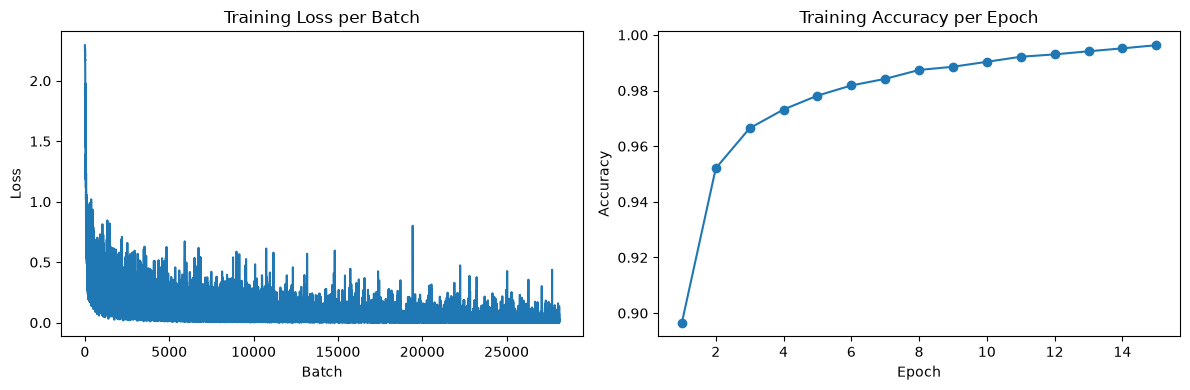

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_title("Training Loss per Batch")
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Loss")

axes[1].plot(range(1, len(accuracies) + 1), accuracies, marker="o")
axes[1].set_title("Training Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Task 7 testing the network

In [11]:
def test(net, dataloader, device="cpu"):
    net.to(device)
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    print("Test Accuracy: {:.4f}".format(accuracy))
    return accuracy

test_accuracy = test(net, test_loader, device=device)

Test Accuracy: 0.9795


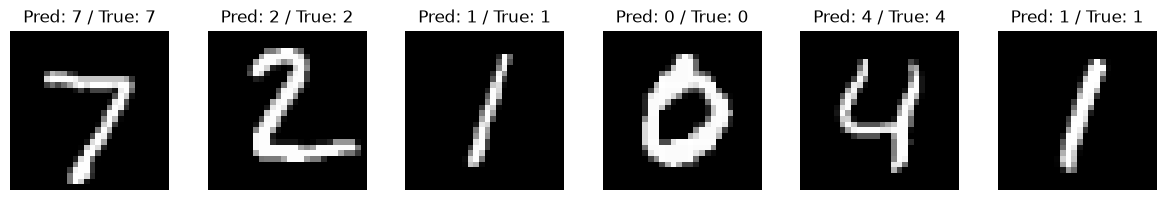

In [12]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = net(images)
_, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(images[i][0].cpu(), cmap="gray")
    axes[i].set_title("Pred: {} / True: {}".format(predicted[i].item(), labels[i].item()))
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# Task 8 Tuning the parameters and model

In [13]:
# tuning the learning rate and momentum

tune_train_subset, tune_val_subset = random_split(train_dataset, [50000, 10000], generator=g)
tune_train_loader = DataLoader(tune_train_subset, batch_size=32, shuffle=True, generator=g)
tune_val_loader = DataLoader(tune_val_subset, batch_size=32, shuffle=False)
TUNE_EPOCHS = 4
lr_values = [0.001, 0.01, 0.1]
lr_results = []
for lr in lr_values:
    print("Testing lr={}".format(lr))
    torch.manual_seed(SEED)
    net_cfg = SimpleNeuralNetwork(hidden_size=128)
    _, _, val_acc_cfg = train(
        net_cfg, tune_train_loader, epochs=TUNE_EPOCHS, lr=lr, momentum=0.9,
        device=device, print_every=10000, val_loader=tune_val_loader
    )
    lr_results.append({"lr": lr, "momentum": 0.9, "val_acc": val_acc_cfg[-1]})
    print("-" * 50)

best_lr = max(lr_results, key=lambda r: r["val_acc"])["lr"]
print("Best learning rate: {} (momentum fixed at 0.9)".format(best_lr))


momentum_values = [0.0, 0.5, 0.9, 0.99]
momentum_results = []
for m in momentum_values:
    print("Testing momentum={}".format(m))
    torch.manual_seed(SEED)
    net_cfg = SimpleNeuralNetwork(hidden_size=128)
    _, _, val_acc_cfg = train(
        net_cfg, tune_train_loader, epochs=TUNE_EPOCHS, lr=best_lr, momentum=m,
        device=device, print_every=10000, val_loader=tune_val_loader
    )
    momentum_results.append({"lr": best_lr, "momentum": m, "val_acc": val_acc_cfg[-1]})
    print("-" * 50)

best_lr_momentum = max(momentum_results, key=lambda r: r["val_acc"])
print("Best lr/momentum config: lr={}, momentum={}".format(
    best_lr_momentum["lr"], best_lr_momentum["momentum"]))
print("Best val accuracy: {:.4f}".format(best_lr_momentum["val_acc"]))

print("\nLR sweep results:", lr_results)
print("Momentum sweep results:", momentum_results)

Testing lr=0.001
Epoch 1 | Batch 0 | Loss: 2.3207
Test Accuracy: 0.8787
Epoch 1 finished | Avg Loss: 0.9561 | Train Acc: 0.7793 | Val Acc: 0.8787
Epoch 2 | Batch 0 | Loss: 0.4507
Test Accuracy: 0.8990
Epoch 2 finished | Avg Loss: 0.4001 | Train Acc: 0.8903 | Val Acc: 0.8990
Epoch 3 | Batch 0 | Loss: 0.2829
Test Accuracy: 0.9058
Epoch 3 finished | Avg Loss: 0.3384 | Train Acc: 0.9043 | Val Acc: 0.9058
Epoch 4 | Batch 0 | Loss: 0.2350
Test Accuracy: 0.9119
Epoch 4 finished | Avg Loss: 0.3072 | Train Acc: 0.9134 | Val Acc: 0.9119
--------------------------------------------------
Testing lr=0.01
Epoch 1 | Batch 0 | Loss: 2.2892
Test Accuracy: 0.9337
Epoch 1 finished | Avg Loss: 0.3842 | Train Acc: 0.8916 | Val Acc: 0.9337
Epoch 2 | Batch 0 | Loss: 0.4012
Test Accuracy: 0.9533
Epoch 2 finished | Avg Loss: 0.1792 | Train Acc: 0.9485 | Val Acc: 0.9533
Epoch 3 | Batch 0 | Loss: 0.1556
Test Accuracy: 0.9601
Epoch 3 finished | Avg Loss: 0.1270 | Train Acc: 0.9638 | Val Acc: 0.9601
Epoch 4 | Bat

In [14]:
# tuning the number of layers and neurons
class TuneNet(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=(256, 128), num_classes=10):
        super(TuneNet, self).__init__()
        layers = []
        in_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        layers.append(nn.Linear(in_size, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.model(x)


BEST_LR = best_lr_momentum["lr"]
BEST_MOMENTUM = best_lr_momentum["momentum"]


width_values = [64, 128, 256, 512]
width_results = []
for w in width_values:
    print("Testing width={}".format(w))
    torch.manual_seed(SEED)
    net_cfg = TuneNet(hidden_sizes=(w,))
    _, _, val_acc_cfg = train(
        net_cfg, tune_train_loader, epochs=TUNE_EPOCHS, lr=BEST_LR, momentum=BEST_MOMENTUM,
        device=device, print_every=10000, val_loader=tune_val_loader
    )
    width_results.append({"hidden_sizes": (w,), "val_acc": val_acc_cfg[-1]})
    print("-" * 50)

best_width = max(width_results, key=lambda r: r["val_acc"])["hidden_sizes"][0]
print("Best single-layer width: {}".format(best_width))


depth_configs = [(best_width,), (best_width, 128), (best_width, 128, 64)]
depth_results = []
for hs in depth_configs:
    print("Testing hidden_sizes={}".format(hs))
    torch.manual_seed(SEED)
    net_cfg = TuneNet(hidden_sizes=hs)
    _, _, val_acc_cfg = train(
        net_cfg, tune_train_loader, epochs=TUNE_EPOCHS, lr=BEST_LR, momentum=BEST_MOMENTUM,
        device=device, print_every=10000, val_loader=tune_val_loader
    )
    depth_results.append({"hidden_sizes": hs, "val_acc": val_acc_cfg[-1]})
    print("-" * 50)

best_architecture = max(depth_results, key=lambda r: r["val_acc"])
print("Best architecture: {}".format(best_architecture["hidden_sizes"]))
print("Best val accuracy: {:.4f}".format(best_architecture["val_acc"]))

print("\nWidth sweep results:", width_results)
print("Depth sweep results:", depth_results)

Testing width=64
Epoch 1 | Batch 0 | Loss: 2.2821
Test Accuracy: 0.9288
Epoch 1 finished | Avg Loss: 0.3933 | Train Acc: 0.8896 | Val Acc: 0.9288
Epoch 2 | Batch 0 | Loss: 0.1112
Test Accuracy: 0.9488
Epoch 2 finished | Avg Loss: 0.1869 | Train Acc: 0.9465 | Val Acc: 0.9488
Epoch 3 | Batch 0 | Loss: 0.0643
Test Accuracy: 0.9545
Epoch 3 finished | Avg Loss: 0.1372 | Train Acc: 0.9605 | Val Acc: 0.9545
Epoch 4 | Batch 0 | Loss: 0.1727
Test Accuracy: 0.9609
Epoch 4 finished | Avg Loss: 0.1105 | Train Acc: 0.9674 | Val Acc: 0.9609
--------------------------------------------------
Testing width=128
Epoch 1 | Batch 0 | Loss: 2.3149
Test Accuracy: 0.9354
Epoch 1 finished | Avg Loss: 0.3839 | Train Acc: 0.8922 | Val Acc: 0.9354
Epoch 2 | Batch 0 | Loss: 0.1390
Test Accuracy: 0.9493
Epoch 2 finished | Avg Loss: 0.1783 | Train Acc: 0.9492 | Val Acc: 0.9493
Epoch 3 | Batch 0 | Loss: 0.1504
Test Accuracy: 0.9630
Epoch 3 finished | Avg Loss: 0.1265 | Train Acc: 0.9645 | Val Acc: 0.9630
Epoch 4 | B

In [15]:
torch.manual_seed(SEED)
final_net = TuneNet(hidden_sizes=best_architecture["hidden_sizes"])
train(final_net, train_loader, epochs=15, lr=BEST_LR, momentum=BEST_MOMENTUM, device=device)
final_test_acc = test(final_net, test_loader, device=device)
print("Final test accuracy with tuned config: {:.4f}".format(final_test_acc))

Epoch 1 | Batch 0 | Loss: 2.3116
Epoch 1 | Batch 200 | Loss: 1.0680
Epoch 1 | Batch 400 | Loss: 0.3851
Epoch 1 | Batch 600 | Loss: 0.3636
Epoch 1 | Batch 800 | Loss: 0.1297
Epoch 1 | Batch 1000 | Loss: 0.0824
Epoch 1 | Batch 1200 | Loss: 0.5954
Epoch 1 | Batch 1400 | Loss: 0.1465
Epoch 1 | Batch 1600 | Loss: 0.2176
Epoch 1 | Batch 1800 | Loss: 0.1045
Epoch 1 finished | Avg Loss: 0.3681 | Train Acc: 0.8908
Epoch 2 | Batch 0 | Loss: 0.1467
Epoch 2 | Batch 200 | Loss: 0.1913
Epoch 2 | Batch 400 | Loss: 0.1206
Epoch 2 | Batch 600 | Loss: 0.0804
Epoch 2 | Batch 800 | Loss: 0.0685
Epoch 2 | Batch 1000 | Loss: 0.2561
Epoch 2 | Batch 1200 | Loss: 0.0882
Epoch 2 | Batch 1400 | Loss: 0.1090
Epoch 2 | Batch 1600 | Loss: 0.1379
Epoch 2 | Batch 1800 | Loss: 0.0330
Epoch 2 finished | Avg Loss: 0.1189 | Train Acc: 0.9641
Epoch 3 | Batch 0 | Loss: 0.0081
Epoch 3 | Batch 200 | Loss: 0.6046
Epoch 3 | Batch 400 | Loss: 0.0171
Epoch 3 | Batch 600 | Loss: 0.2038
Epoch 3 | Batch 800 | Loss: 0.1260
Epoch 3 |